In [1]:
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, IntegrationWarning
from numba import njit, prange, get_num_threads
import numba

from IPython.display import display

%matplotlib inline

SEED = 42
np.random.seed(SEED)
S0 = 100.0
T_START = time.perf_counter()

import os
os.makedirs("figures", exist_ok=True)

# the Q2 benchmark contract: at the money, one year, barrier at 85
DEMO = dict(K=100.0, T=1.0, r=0.03, q=0.01, B=85.0,
            v0=0.04, theta=0.06, kappa=2.0, eta=0.4, rho=-0.7)

pd.set_option("display.width", 140)
print(f"numba {numba.__version__} | threads available: {get_num_threads()}")

numba 0.65.1 | threads available: 8


## 1. The measuring stick: work-normalised variance

A Monte Carlo price is a sample mean over $M$ independent units (paths, or path-pairs), with standard error $\mathrm{SE} = \sqrt{v/M}$ where $v$ is the per-unit variance, and a cost $T = c\,M$ where $c$ is the time per unit. The time needed to reach a target accuracy $\varepsilon$ is therefore

$$T(\varepsilon) = c \cdot \frac{v}{\varepsilon^2},$$

so the figure of merit for any estimator is the product $c \cdot v$, its work-normalised variance (Glasserman 2004, ch.\ 4 calls this the efficiency comparison). The equal-accuracy speedup of method 2 over method 1 is $(c_1 v_1)/(c_2 v_2)$. Engineering improvements lower $c$ and leave $v$ alone; variance reduction lowers $v$ and (mostly) leaves $c$ alone; the two multiply. This metric keeps us honest in both directions: a JIT rewrite that is slower per path counts against, and a variance-reduction trick that doubles the per-path cost must at least halve the variance to break even.

Throughout Sections 2 to 4 every estimator prices the same benchmark contract, the at-the-money one-year down-and-out call with $B = 85$ used as the demonstration contract in Q2, on the same daily Euler grid, so all of them estimate the same quantity (one small and disclosed nuance for the control variate in Section 3.2). Prices and standard errors are printed at every step so agreement between methods is visible, not assumed.

## 2. Engineering: the same estimator, computed faster

### 2.1 Baseline ladder from Q2: the loop and the vectorised engine

The two rungs below were already built in Q2 and are re-measured here so the whole ladder sits in one place: the Lab 10 style pure-Python loop, and the NumPy path-vectorised version that generated dataset B (identical scheme, the Python loop runs only over time steps).

In [2]:
def mc_loop(K, T, r, q, B, v0, theta, kappa, eta, rho,
            n_paths=2000, steps_per_year=252, seed=0):
    # Lab 10 style: explicit loops over paths and steps (the original Euler MC)
    rng = np.random.default_rng(seed)
    n_steps = max(int(np.ceil(steps_per_year * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho**2)
    payoff_sum = 0.0
    for _ in range(n_paths):
        S, v, alive = S0, v0, True
        for _ in range(n_steps):
            zv = rng.standard_normal()
            zs = rho * zv + srho * rng.standard_normal()
            vp = max(v, 0.0)
            S = S * np.exp((r - q - 0.5 * vp) * dt + np.sqrt(vp) * sqdt * zs)
            v = v + kappa * (theta - vp) * dt + eta * np.sqrt(vp) * sqdt * zv
            if S <= B:
                alive = False
                break
        if alive:
            payoff_sum += max(S - K, 0.0)
    return np.exp(-r * T) * payoff_sum / n_paths

def mc_vec(K, T, r, q, B, v0, theta, kappa, eta, rho,
           n_paths=20000, steps_per_year=252, seed=0):
    # Q2 production engine: same scheme, vectorised across paths.
    # Returns the discounted per-path payoffs so variance can be measured.
    rng = np.random.default_rng(seed)
    n_steps = max(int(np.ceil(steps_per_year * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho**2)
    S = np.full(n_paths, S0)
    v = np.full(n_paths, float(v0))
    alive = np.ones(n_paths, dtype=bool)
    for _ in range(n_steps):
        Z = rng.standard_normal((2, n_paths))
        zv = Z[0]
        zs = rho * zv + srho * Z[1]
        vp = np.maximum(v, 0.0)
        sq = np.sqrt(vp)
        S = S * np.exp((r - q - 0.5 * vp) * dt + sq * sqdt * zs)
        v = v + kappa * (theta - vp) * dt + eta * sq * sqdt * zv
        alive &= S > B
    return np.where(alive, np.maximum(S - K, 0.0), 0.0) * np.exp(-r * T)

def report(name, pay, seconds, n_units, unit="path"):
    m = pay.mean()
    var = pay.var(ddof=1)
    se = np.sqrt(var / n_units)
    print(f"{name:34s} {m:7.4f} +/- {se:.4f} | {seconds:6.2f} s for {n_units:>7,} {unit}s "
          f"| var/{unit} {var:7.2f}")
    return dict(price=m, se=se, var=var, sec=seconds, units=n_units)

M = 100_000
t0 = time.perf_counter(); p_loop = mc_loop(n_paths=2000, seed=SEED, **DEMO); t_loop2k = time.perf_counter() - t0
print(f"pure Python loop: {p_loop:.4f} | {t_loop2k:.2f} s for 2,000 paths "
      f"-> {t_loop2k / 2000 * 1e3:.2f} ms per path")

t0 = time.perf_counter(); pay_vec = mc_vec(n_paths=M, seed=SEED + 1, **DEMO); t_vec = time.perf_counter() - t0
res_vec = report("NumPy vectorised (Q2 engine)", pay_vec, t_vec, M)
C_LOOP = t_loop2k / 2000                       # seconds per path, loop
C_VEC = t_vec / M                              # seconds per path, vectorised
print(f"\nengineering gain already banked in Q2: {C_LOOP / C_VEC:.0f}x per path")

pure Python loop: 8.9719 | 2.08 s for 2,000 paths -> 1.04 ms per path


NumPy vectorised (Q2 engine)        8.6751 +/- 0.0390 |   2.00 s for 100,000 paths | var/path  152.44

engineering gain already banked in Q2: 52x per path


### 2.2 Just-in-time compilation with Numba

The vectorised engine still pays NumPy's costs: a dozen temporary 100,000-element arrays allocated at every one of the 252 steps, and no way to stop simulating a path that has already knocked out (the `alive` mask keeps dead paths in every computation). A compiled per-path loop removes both: Numba's `@njit` turns the Python loop into machine code with no temporaries, the inner loop can `break` the moment the barrier is hit, and `parallel=True` with `prange` spreads paths across cores. The compilation cost is a one-off of a few seconds, paid the first time the kernel is called.

Numba's parallel random number generation gives each thread its own stream, and the assignment of work to threads is not fixed, so the parallel kernel is not bit-reproducible run to run even with a fixed seed (the serial kernel is). For dataset generation, where reproducibility matters, we therefore prefer the seeded NumPy engines and treat parallel Numba as the throughput option.

In [3]:
@njit(cache=True)
def mc_numba_serial(K, T, r, q, B, v0, theta, kappa, eta, rho,
                    n_paths, steps_per_year, seed):
    np.random.seed(seed)
    n_steps = max(int(np.ceil(steps_per_year * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho * rho)
    disc = np.exp(-r * T)
    out = np.empty(n_paths)
    for i in range(n_paths):
        S, v, alive = S0, v0, True
        for _ in range(n_steps):
            zv = np.random.normal(0.0, 1.0)
            zs = rho * zv + srho * np.random.normal(0.0, 1.0)
            vp = v if v > 0.0 else 0.0
            sq = np.sqrt(vp)
            S = S * np.exp((r - q - 0.5 * vp) * dt + sq * sqdt * zs)
            v = v + kappa * (theta - vp) * dt + eta * sq * sqdt * zv
            if S <= B:                      # early exit: dead paths stop computing
                alive = False
                break
        out[i] = disc * (S - K) if (alive and S > K) else 0.0
    return out

@njit(cache=True, parallel=True)
def mc_numba_parallel(K, T, r, q, B, v0, theta, kappa, eta, rho,
                      n_paths, steps_per_year, seed):
    np.random.seed(seed)
    n_steps = max(int(np.ceil(steps_per_year * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho * rho)
    disc = np.exp(-r * T)
    out = np.empty(n_paths)
    for i in prange(n_paths):
        S, v, alive = S0, v0, True
        for _ in range(n_steps):
            zv = np.random.normal(0.0, 1.0)
            zs = rho * zv + srho * np.random.normal(0.0, 1.0)
            vp = v if v > 0.0 else 0.0
            sq = np.sqrt(vp)
            S = S * np.exp((r - q - 0.5 * vp) * dt + sq * sqdt * zs)
            v = v + kappa * (theta - vp) * dt + eta * sq * sqdt * zv
            if S <= B:
                alive = False
                break
        out[i] = disc * (S - K) if (alive and S > K) else 0.0
    return out

# one-off compilation (excluded from the benchmarks, reported for honesty)
t0 = time.perf_counter()
mc_numba_serial(n_paths=100, steps_per_year=252, seed=1, **DEMO)
mc_numba_parallel(n_paths=100, steps_per_year=252, seed=1, **DEMO)
print(f"one-off Numba compilation: {time.perf_counter() - t0:.1f} s")

t0 = time.perf_counter(); pay_nbs = mc_numba_serial(n_paths=M, steps_per_year=252, seed=SEED + 2, **DEMO); t_nbs = time.perf_counter() - t0
res_nbs = report("Numba JIT, serial", pay_nbs, t_nbs, M)

t0 = time.perf_counter(); pay_nbp = mc_numba_parallel(n_paths=M, steps_per_year=252, seed=SEED + 3, **DEMO); t_nbp = time.perf_counter() - t0
res_nbp = report(f"Numba JIT, parallel ({get_num_threads()} threads)", pay_nbp, t_nbp, M)

zs_ = (res_nbs["price"] - res_vec["price"]) / np.sqrt(res_nbs["se"]**2 + res_vec["se"]**2)
zp_ = (res_nbp["price"] - res_vec["price"]) / np.sqrt(res_nbp["se"]**2 + res_vec["se"]**2)
print(f"\nagreement with the vectorised engine: serial {zs_:+.2f} SEs, parallel {zp_:+.2f} SEs")
two = mc_numba_parallel(n_paths=M, steps_per_year=252, seed=SEED + 3, **DEMO)
print(f"parallel kernel bit-reproducible with the same seed: {bool(np.isclose(two.mean(), pay_nbp.mean(), atol=1e-12))}")

one-off Numba compilation: 0.9 s


Numba JIT, serial                   8.6948 +/- 0.0391 |   2.56 s for 100,000 paths | var/path  153.20


Numba JIT, parallel (8 threads)     8.6406 +/- 0.0390 |   0.59 s for 100,000 paths | var/path  152.08

agreement with the vectorised engine: serial +0.36 SEs, parallel -0.63 SEs


parallel kernel bit-reproducible with the same seed: False


## 3. Statistics: the same accuracy, from fewer paths

### 3.1 Antithetic variates

For every standard normal draw $Z$ used by the scheme, the mirrored draw $-Z$ is equally likely, so simulating paths in pairs that share the same uniforms with flipped signs and averaging each pair's payoffs gives an unbiased estimator whose per-pair variance is $\tfrac{1}{2}(\mathrm{Var}[Y] + \mathrm{Cov}[Y^+, Y^-])$. When the payoff is broadly monotone in the shocks, the pair covariance is negative and the variance per unit of work falls (Glasserman 2004, sec. 4.2). A down-and-out call is such a payoff: up-shocks raise it, down-shocks knock it out. A pleasant side effect is that the pair needs only one set of random numbers for two paths, so it also shaves generation cost.

The implementation below simulates the pair jointly and returns two things per pair: the barrier payoff average $Y$ (the estimator) and, for the next subsection, the European call payoff average $X$ on the same paths. One structural cost is noted: the European payoff needs $S_T$ on every path, so the early-exit trick of the JIT loop is unavailable once we carry the control variate.

In [4]:
def mc_anti_cv(K, T, r, q, B, v0, theta, kappa, eta, rho,
               n_pairs=50000, steps_per_year=252, seed=0):
    # Antithetic pair simulation; returns per-pair (Y, X):
    # Y = down-and-out call payoff average, X = European call payoff average,
    # both discounted, both on the same random numbers.
    rng = np.random.default_rng(seed)
    n_steps = max(int(np.ceil(steps_per_year * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho**2)
    S1 = np.full(n_pairs, S0); S2 = np.full(n_pairs, S0)
    v1 = np.full(n_pairs, float(v0)); v2 = np.full(n_pairs, float(v0))
    a1 = np.ones(n_pairs, dtype=bool); a2 = np.ones(n_pairs, dtype=bool)
    for _ in range(n_steps):
        Z = rng.standard_normal((2, n_pairs))
        for sgn, S, v, a in ((1.0, S1, v1, a1), (-1.0, S2, v2, a2)):
            zv = sgn * Z[0]
            zs = rho * zv + srho * sgn * Z[1]
            vp = np.maximum(v, 0.0)
            sq = np.sqrt(vp)
            S *= np.exp((r - q - 0.5 * vp) * dt + sq * sqdt * zs)
            v += kappa * (theta - vp) * dt + eta * sq * sqdt * zv
            a &= S > B
    disc = np.exp(-r * T)
    eu1 = disc * np.maximum(S1 - K, 0.0)
    eu2 = disc * np.maximum(S2 - K, 0.0)
    Y = 0.5 * (np.where(a1, eu1, 0.0) + np.where(a2, eu2, 0.0))
    X = 0.5 * (eu1 + eu2)
    return Y, X

t0 = time.perf_counter(); Y_anti, X_anti = mc_anti_cv(n_pairs=M // 2, seed=SEED + 4, **DEMO); t_anti = time.perf_counter() - t0
res_anti = report("vectorised + antithetic", Y_anti, t_anti, M // 2, unit="pair")
ratio_budget = res_vec["var"] / (2 * res_anti["var"])
print(f"\nvariance per equal path budget: plain {res_vec['var']:.1f} vs antithetic "
      f"{2 * res_anti['var']:.1f} -> {ratio_budget:.2f}x lower")

vectorised + antithetic             8.7012 +/- 0.0286 |   1.35 s for  50,000 pairs | var/pair   41.01

variance per equal path budget: plain 152.4 vs antithetic 82.0 -> 1.86x lower


### 3.2 A control variate from the Q2 validation apparatus

A control variate adjusts the estimator with a correlated quantity whose true mean is known:

$$\bar Y_{cv} = \bar Y - \beta\,(\bar X - \mathbb{E}[X]), \qquad
\beta^* = \frac{\mathrm{Cov}(Y, X)}{\mathrm{Var}(X)}, \qquad
\frac{\mathrm{Var}[\bar Y_{cv}]}{\mathrm{Var}[\bar Y]} = 1 - \rho^2_{Y\!X},$$

so everything hinges on finding an $X$ that is cheap, highly correlated with $Y$, and has a known mean. Our solution to Q2 supplies one ready-made: the **European call payoff on the same simulated paths**. It costs nothing extra to compute (the terminal prices are already there), its correlation with the down-and-out payoff is high by construction (the two payoffs are literally identical on every path that does not knock out), and its exact expectation under Heston is known semi-analytically from the characteristic-function pricer we built to validate the Q2 engine (Heston 1993, in the trap-free form of Albrecher et al. 2007). The coefficient $\beta$ is estimated from the same sample, which introduces a bias of order $1/M$ that is negligible at these sizes (Glasserman 2004, sec. 4.1).

**Note:** the analytic $\mathbb{E}[X]$ is exact for the Heston model, while the simulated $X$ carries the Euler scheme's $O(\Delta t)$ weak bias at daily steps. Using the exact mean therefore shifts the estimand by $\beta$ times that small discretisation gap. Q2's validation measured the gap to be statistically invisible at 40,000 paths (the European MC sat $0.7$ standard errors from the analytic price), and Section 5 checks the end-to-end effect empirically against the stored Q2 labels. The bias-free alternative, estimating $\mathbb{E}[X]$ by a one-off very long simulation of the same scheme, would restore exactness at the cost of a pilot run; for label generation at our accuracy it is not needed.

In [5]:
def heston_call_analytic(K, T, r, q, v0, theta, kappa, eta, rho):
    # Heston (1993) semi-analytic European call, little-trap form (from TCPS2Q2)
    x = np.log(S0) + (r - q) * T

    def cf(u):
        iu = 1j * u
        d = np.sqrt((rho * eta * iu - kappa) ** 2 + eta**2 * (iu + u**2))
        g = (kappa - rho * eta * iu - d) / (kappa - rho * eta * iu + d)
        ee = np.exp(-d * T)
        Cf = (kappa * theta / eta**2) * ((kappa - rho * eta * iu - d) * T
                                         - 2.0 * np.log((1 - g * ee) / (1 - g)))
        Df = ((kappa - rho * eta * iu - d) / eta**2) * (1 - ee) / (1 - g * ee)
        return np.exp(Cf + Df * v0 + iu * x)

    lnK = np.log(K)
    phi_mi = cf(-1j).real
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", IntegrationWarning)
        I1 = quad(lambda u: (np.exp(-1j * u * lnK) * cf(u - 1j) / (1j * u * phi_mi)).real,
                  1e-10, 200, limit=400)[0]
        I2 = quad(lambda u: (np.exp(-1j * u * lnK) * cf(u) / (1j * u)).real,
                  1e-10, 200, limit=400)[0]
    return S0 * np.exp(-q * T) * (0.5 + I1 / np.pi) - K * np.exp(-r * T) * (0.5 + I2 / np.pi)

def cv_adjust(Y, X, EX):
    vx = X.var(ddof=1)
    beta = np.cov(Y, X)[0, 1] / vx if vx > 0 else 0.0   # dead contracts: no adjustment
    Ycv = Y - beta * (X - EX)
    return Ycv, beta

EX_DEMO = heston_call_analytic(**{k: v for k, v in DEMO.items() if k != "B"})
print(f"analytic European Heston call (control mean): {EX_DEMO:.4f}")

# control variate on plain paths (no antithetic): isolate its own contribution
def mc_vec_cv(n_paths, seed, **pars):
    # plain paths, returning per-path (Y, X); same loop as mc_vec with X kept
    rng = np.random.default_rng(seed)
    K, T, r, q, B = pars["K"], pars["T"], pars["r"], pars["q"], pars["B"]
    v0, theta, kappa, eta, rho = pars["v0"], pars["theta"], pars["kappa"], pars["eta"], pars["rho"]
    n_steps = max(int(np.ceil(252 * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho**2)
    S = np.full(n_paths, S0)
    v = np.full(n_paths, float(v0))
    alive = np.ones(n_paths, dtype=bool)
    for _ in range(n_steps):
        Z = rng.standard_normal((2, n_paths))
        zv = Z[0]
        zs = rho * zv + srho * Z[1]
        vp = np.maximum(v, 0.0)
        sq = np.sqrt(vp)
        S = S * np.exp((r - q - 0.5 * vp) * dt + sq * sqdt * zs)
        v = v + kappa * (theta - vp) * dt + eta * sq * sqdt * zv
        alive &= S > B
    disc = np.exp(-r * T)
    eu = disc * np.maximum(S - K, 0.0)
    return np.where(alive, eu, 0.0), eu

t0 = time.perf_counter(); Yp, Xp = mc_vec_cv(n_paths=M, seed=SEED + 5, **DEMO); t_pcv = time.perf_counter() - t0
Ycv_plain, beta_plain = cv_adjust(Yp, Xp, EX_DEMO)
rho_plain = np.corrcoef(Yp, Xp)[0, 1]
res_pcv = report("vectorised + control variate", Ycv_plain, t_pcv, M)
print(f"  corr(Y, X) = {rho_plain:.4f} | beta = {beta_plain:.3f} | "
      f"variance ratio vs plain: {res_vec['var'] / res_pcv['var']:.1f}x")

# combined: antithetic + control variate (reusing the Section 3.1 sample)
Ycv_anti, beta_anti = cv_adjust(Y_anti, X_anti, EX_DEMO)
res_combo = report("vectorised + antithetic + CV", Ycv_anti, t_anti, M // 2, unit="pair")
print(f"  corr(Y, X) on pairs = {np.corrcoef(Y_anti, X_anti)[0, 1]:.4f} | beta = {beta_anti:.3f}")

analytic European Heston call (control mean): 9.4918


vectorised + control variate        8.7123 +/- 0.0114 |   1.69 s for 100,000 paths | var/path   13.06
  corr(Y, X) = 0.9567 | beta = 0.958 | variance ratio vs plain: 11.7x
vectorised + antithetic + CV        8.6791 +/- 0.0116 |   1.35 s for  50,000 pairs | var/pair    6.76
  corr(Y, X) on pairs = 0.9138 | beta = 0.992


### 3.3 Stacking statistics on the parallel kernel

The statistical improvements are estimator-level and the engineering improvements are implementation-level, so they compose: the last rung is a parallel Numba kernel that simulates antithetic pairs and returns $(Y, X)$ per pair, to which the same control adjustment is applied. (Per the Section 2 caveat, this rung trades bit-reproducibility for throughput.)

In [6]:
@njit(cache=True, parallel=True)
def mc_numba_anti_cv(K, T, r, q, B, v0, theta, kappa, eta, rho,
                     n_pairs, steps_per_year, seed):
    np.random.seed(seed)
    n_steps = max(int(np.ceil(steps_per_year * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho * rho)
    disc = np.exp(-r * T)
    Y = np.empty(n_pairs)
    X = np.empty(n_pairs)
    for i in prange(n_pairs):
        S1, v1, a1 = S0, v0, True
        S2, v2, a2 = S0, v0, True
        for _ in range(n_steps):
            zv = np.random.normal(0.0, 1.0)
            e = np.random.normal(0.0, 1.0)
            zs = rho * zv + srho * e
            vp1 = v1 if v1 > 0.0 else 0.0
            sq1 = np.sqrt(vp1)
            S1 = S1 * np.exp((r - q - 0.5 * vp1) * dt + sq1 * sqdt * zs)
            v1 = v1 + kappa * (theta - vp1) * dt + eta * sq1 * sqdt * zv
            if S1 <= B:
                a1 = False
            vp2 = v2 if v2 > 0.0 else 0.0
            sq2 = np.sqrt(vp2)
            S2 = S2 * np.exp((r - q - 0.5 * vp2) * dt - sq2 * sqdt * zs)
            v2 = v2 + kappa * (theta - vp2) * dt - eta * sq2 * sqdt * zv
            if S2 <= B:
                a2 = False
        eu1 = disc * (S1 - K) if S1 > K else 0.0
        eu2 = disc * (S2 - K) if S2 > K else 0.0
        Y[i] = 0.5 * ((eu1 if a1 else 0.0) + (eu2 if a2 else 0.0))
        X[i] = 0.5 * (eu1 + eu2)
    return Y, X

t0 = time.perf_counter()
mc_numba_anti_cv(n_pairs=100, steps_per_year=252, seed=1, **DEMO)
print(f"one-off compilation: {time.perf_counter() - t0:.1f} s")

t0 = time.perf_counter()
Y_nb, X_nb = mc_numba_anti_cv(n_pairs=M // 2, steps_per_year=252, seed=SEED + 6, **DEMO)
t_nbcv = time.perf_counter() - t0
Ycv_nb, beta_nb = cv_adjust(Y_nb, X_nb, EX_DEMO)
res_nbcv = report("Numba parallel + antithetic + CV", Ycv_nb, t_nbcv, M // 2, unit="pair")
z_nb = (res_nbcv["price"] - res_vec["price"]) / np.sqrt(res_nbcv["se"]**2 + res_vec["se"]**2)
print(f"  agreement with the plain vectorised price: {z_nb:+.2f} SEs")

one-off compilation: 0.1 s


Numba parallel + antithetic + CV    8.6884 +/- 0.0115 |   0.60 s for  50,000 pairs | var/pair    6.65
  agreement with the plain vectorised price: +0.33 SEs


## 4. The efficiency ladder

The table below puts every rung on the common yardstick of Section 1: cost per unit $c$, variance per unit $v$, their product $c \cdot v$, and the equal-accuracy speedup relative to the original loop and relative to the Q2 production engine. The pure loop shares its estimator (and therefore its variance) with the vectorised engine, so its variance is taken from the vectorised sample and only its per-path cost was measured directly.

,time per unit (us),var per unit,c x v,speedup vs loop,speedup vs Q2 engine
method,,,,,
pure Python loop (Lab 10 style),1039.158,152.439,0.158,1.000,0.019
NumPy vectorised (Q2 engine),20.004,152.439,0.003,51.949,1.000
Numba JIT serial,25.639,153.200,0.004,40.329,0.776
Numba JIT parallel (8 thr),5.900,152.077,0.001,176.539,3.398
vectorised + antithetic,27.063,41.008,0.001,142.737,2.748
vectorised + control variate,16.905,13.059,0.000,717.547,13.813
vectorised + antithetic + CV,27.063,6.763,0.000,865.480,16.660
Numba parallel + antithetic + CV,11.956,6.647,0.000,1993.285,38.370


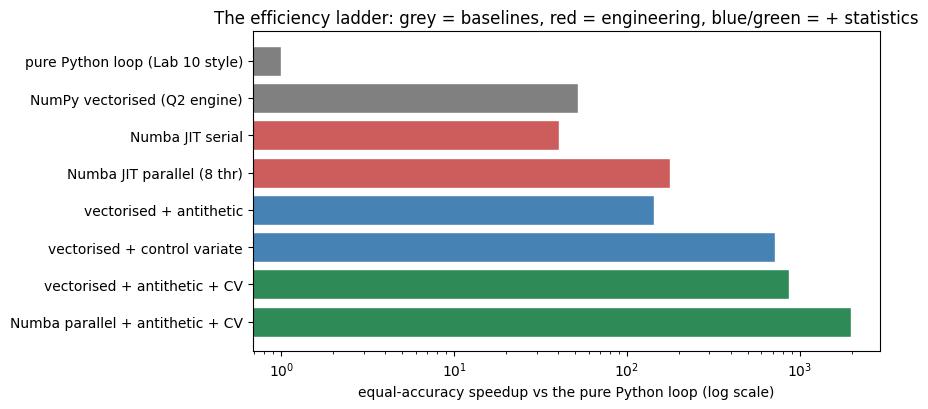

In [7]:
rows = []
def ladder_row(name, c, v):
    rows.append(dict(method=name, **{"time per unit (us)": c * 1e6, "var per unit": v,
                                     "c x v": c * v}))

ladder_row("pure Python loop (Lab 10 style)", C_LOOP, res_vec["var"])
ladder_row("NumPy vectorised (Q2 engine)", C_VEC, res_vec["var"])
ladder_row("Numba JIT serial", t_nbs / M, res_nbs["var"])
ladder_row(f"Numba JIT parallel ({get_num_threads()} thr)", t_nbp / M, res_nbp["var"])
ladder_row("vectorised + antithetic", t_anti / (M // 2), res_anti["var"])
ladder_row("vectorised + control variate", t_pcv / M, res_pcv["var"])
ladder_row("vectorised + antithetic + CV", t_anti / (M // 2), res_combo["var"])
ladder_row("Numba parallel + antithetic + CV", t_nbcv / (M // 2), res_nbcv["var"])

ladder = pd.DataFrame(rows).set_index("method")
ladder["speedup vs loop"] = ladder["c x v"].iloc[0] / ladder["c x v"]
ladder["speedup vs Q2 engine"] = ladder["c x v"].iloc[1] / ladder["c x v"]
ladder.to_csv("figures/table_q3_ladder.csv")
display(ladder.round(3))

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = ["grey", "grey", "indianred", "indianred", "steelblue", "steelblue", "seagreen", "seagreen"]
ax.barh(ladder.index[::-1], ladder["speedup vs loop"][::-1], color=colors[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("equal-accuracy speedup vs the pure Python loop (log scale)")
ax.set_title("The efficiency ladder: grey = baselines, red = engineering, blue/green = + statistics")
plt.tight_layout()
plt.savefig("figures/fig_q3_ladder.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.1 Where the gains come from, and when they shrink

The control variate's power is the correlation $\rho_{Y\!X}$, and that correlation is a function of the contract: it is high when knock-out is rare (the barrier payoff is then nearly the European payoff) and must fall as the barrier rises towards the spot. The cell below repeats the headline measurement across barrier levels, holding everything else at the benchmark values, to show how much of the speedup survives in the hardest corner of the Q2 parameter box.

In [8]:
def ko_share(B, n_paths=20000, seed=0):
    pars = dict(DEMO, B=B)
    rng = np.random.default_rng(seed)
    n_steps = 252
    dt = pars["T"] / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - pars["rho"]**2)
    S = np.full(n_paths, S0)
    v = np.full(n_paths, pars["v0"])
    alive = np.ones(n_paths, dtype=bool)
    for _ in range(n_steps):
        Z = rng.standard_normal((2, n_paths))
        zv = Z[0]
        zs = pars["rho"] * zv + srho * Z[1]
        vp = np.maximum(v, 0.0)
        sq = np.sqrt(vp)
        S = S * np.exp((pars["r"] - pars["q"] - 0.5 * vp) * dt + sq * sqdt * zs)
        v = v + pars["kappa"] * (pars["theta"] - vp) * dt + pars["eta"] * sq * sqdt * zv
        alive &= S > pars["B"]
    return 1.0 - alive.mean()

bar_rows = []
for B in (65.0, 80.0, 90.0, 95.0):
    pars = dict(DEMO, B=B)
    pay_b = mc_vec(n_paths=50000, seed=SEED + 10, **pars)
    Yb, Xb = mc_anti_cv(n_pairs=25000, seed=SEED + 11, **pars)
    Ycv_b, _ = cv_adjust(Yb, Xb, EX_DEMO)          # E[X] does not involve B
    c_plain = C_VEC
    c_pair = t_anti / (M // 2)
    speedup = (c_plain * pay_b.var(ddof=1)) / (c_pair * Ycv_b.var(ddof=1))
    bar_rows.append({"B": B, "P(knock-out)": ko_share(B, seed=SEED + 12),
                     "corr(Y, X)": np.corrcoef(Yb, Xb)[0, 1],
                     "var/path (plain)": pay_b.var(ddof=1),
                     "var/pair (anti+CV)": Ycv_b.var(ddof=1),
                     "equal-accuracy speedup vs Q2 engine": speedup})
bar_tab = pd.DataFrame(bar_rows).set_index("B")
bar_tab.to_csv("figures/table_q3_barrier.csv")
display(bar_tab.round(3))

,P(knock-out),"corr(Y, X)",var/path (plain),var/pair (anti+CV),equal-accuracy speedup vs Q2 engine
B,,,,,
65.0,0.103,0.999,157.097,0.043,2725.340
80.0,0.318,0.970,157.594,2.237,52.080
90.0,0.578,0.820,151.841,15.274,7.348
95.0,0.752,0.637,123.456,28.151,3.242


### 4.2 The lever we refuse to pull: fewer time steps

For a European payoff one could trade weak bias against speed by enlarging $\Delta t$. For this contract one cannot, and it is worth demonstrating rather than asserting: the step grid is the monitoring grid, so coarsening it does not approximate the same option less accurately, it prices a different option. The cell prices the benchmark contract with the barrier checked every other day, daily (the contract), and twice daily. Fittingly, the demonstration uses the combined estimator of Section 3: with plain Monte Carlo at this budget the three prices would be barely distinguishable from noise, and the tight error bars that make the contract effect unmistakable are themselves a first practical dividend of the variance reduction.

In [9]:
for spy, lab in ((126, "every other day"), (252, "daily (the contract)"), (504, "twice daily")):
    Y, X = mc_anti_cv(n_pairs=50000, steps_per_year=spy, seed=SEED + 20, **DEMO)
    Ycv, _ = cv_adjust(Y, X, EX_DEMO)
    print(f"monitoring {lab:22s}: {Ycv.mean():7.4f} +/- {Ycv.std(ddof=1)/np.sqrt(len(Ycv)):.4f}")

monitoring every other day       :  8.7454 +/- 0.0111


monitoring daily (the contract)  :  8.6848 +/- 0.0116


monitoring twice daily           :  8.6515 +/- 0.0118


## 5. The payoff in our solution to 2: regenerating dataset B

The improvements only matter if they speed up the task Q2 actually performs, so we close the loop: re-price a random 100 of the 1000 rows of `dataset_q2_barrier.csv` with the combined estimator, at **matched accuracy**, targeting each row's own recorded Q2 standard error. The scheme is adaptive: a 1000-pair pilot estimates the row's control coefficient and post-CV variance, the pair budget needed to hit the row's target SE follows from $M = v/\varepsilon^2$, the extra pairs (if any) are simulated and pooled, and the analytic control mean $\mathbb{E}[X]$ is computed per row with the semi-analytic pricer. We use the seeded NumPy implementation, not the parallel kernel, so the regenerated labels are exactly reproducible like the Q2 originals. All overheads (pilot, analytic mean, bookkeeping) are charged to the measured time.

The comparison against the stored Q2 labels doubles as an end-to-end correctness test: with independent random numbers, the standardised differences $z_i = (\hat p_i^{new} - \hat p_i^{Q2}) / \sqrt{\mathrm{SE}_{new,i}^2 + \mathrm{SE}_{Q2,i}^2}$ should look standard normal, and their mean is a direct probe of the control-variate estimand nuance from Section 3.2.

re-priced 100 rows in 6.8 s (of which analytic control means 0.3 s)
Q2 engine took ~26 s for 100 rows -> wall-clock speedup 3.8x at matched accuracy
full 1000-row dataset: ~68 s instead of Q2's 261 s

accuracy: mean target SE 0.1101 | mean achieved SE 0.0644
mean pair budget 1550 (vs 20,000 paths per row in Q2)
agreement: share |z| <= 2: 95% | mean z +0.05 | sd z 0.97


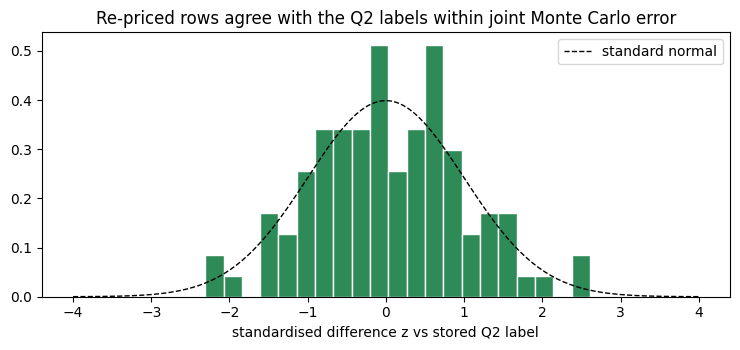

In [10]:
data_bar = pd.read_csv("dataset_q2_barrier.csv")
assert len(data_bar) == 1000, "dataset_q2_barrier.csv not found or unexpected; run TCPS2Q2.ipynb first"
BAR_COLS = ["K", "T", "r", "q", "B", "v0", "theta", "kappa", "eta", "rho"]

rng_pick = np.random.default_rng(SEED)
pick = np.sort(rng_pick.choice(len(data_bar), size=100, replace=False))

t0 = time.perf_counter()
out_rows = []
t_analytic = 0.0
for j, i in enumerate(pick):
    row = data_bar.iloc[i]
    pars = {c: float(row[c]) for c in BAR_COLS}
    se_target = float(row["mc_se"])
    ta = time.perf_counter()
    EX = heston_call_analytic(**{k: v for k, v in pars.items() if k != "B"})
    t_analytic += time.perf_counter() - ta
    Y, X = mc_anti_cv(n_pairs=1000, seed=SEED * 2000 + i, **pars)
    Ycv, _ = cv_adjust(Y, X, EX)
    needed = int(np.ceil(Ycv.var(ddof=1) / se_target**2))
    extra = int(np.clip(needed - 1000, 0, 40000))
    if extra > 0:
        Y2, X2 = mc_anti_cv(n_pairs=extra, seed=SEED * 2000 + i + 500000, **pars)
        Y = np.concatenate([Y, Y2]); X = np.concatenate([X, X2])
        Ycv, _ = cv_adjust(Y, X, EX)
    price = Ycv.mean()
    se = Ycv.std(ddof=1) / np.sqrt(len(Ycv))
    z = (price - row["price"]) / np.sqrt(se**2 + se_target**2)
    out_rows.append(dict(row_idx=i, q2_price=row["price"], q2_se=se_target,
                         new_price=price, new_se=se, pairs=len(Ycv), z=z))
T_REGEN = time.perf_counter() - t0

regen = pd.DataFrame(out_rows)
regen.to_csv("figures/table_q3_regen.csv", index=False)
T_Q2_100 = 0.261 * 100         # Q2 measured 261 ms per option over the full dataset
print(f"re-priced 100 rows in {T_REGEN:.1f} s (of which analytic control means {t_analytic:.1f} s)")
print(f"Q2 engine took ~{T_Q2_100:.0f} s for 100 rows -> wall-clock speedup {T_Q2_100 / T_REGEN:.1f}x at matched accuracy")
print(f"full 1000-row dataset: ~{T_REGEN * 10:.0f} s instead of Q2's 261 s")
print(f"\naccuracy: mean target SE {regen.q2_se.mean():.4f} | mean achieved SE {regen.new_se.mean():.4f}")
print(f"mean pair budget {regen.pairs.mean():.0f} (vs 20,000 paths per row in Q2)")
print(f"agreement: share |z| <= 2: {(regen.z.abs() <= 2).mean():.0%} | mean z {regen.z.mean():+.2f} "
      f"| sd z {regen.z.std(ddof=1):.2f}")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(regen.z, bins=21, density=True, color="seagreen", edgecolor="white")
xs = np.linspace(-4, 4, 200)
ax.plot(xs, np.exp(-xs**2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="standard normal")
ax.set_xlabel("standardised difference z vs stored Q2 label")
ax.set_title("Re-priced rows agree with the Q2 labels within joint Monte Carlo error")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_q3_regen_z.png", dpi=150, bbox_inches="tight")
plt.show()